# Bộ dữ Liệu phân tích về khách hàng
### (olist_customers_dataset.csv)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pathlib
from pathlib import Path
# from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR


In [2]:
customers_data = pd.read_csv("../../data/raw/olist_customers_dataset.csv")

In [3]:
display(customers_data.head())
print(customers_data.shape)
customers_data.dtypes


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


(99441, 5)


customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [4]:
# đến số lượng giá trị thiếu trong mỗi cột
print(customers_data.isna().sum())

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [5]:
print(customers_data['customer_unique_id'].value_counts())
print("\nBao nhiêu người dùng chỉ có 1 đơn hàng?")
print((customers_data['customer_unique_id'].value_counts() == 1).sum())
print("Bao nhiêu người dùng có nhiều hơn 1 đơn hàng?")
print((customers_data['customer_unique_id'].value_counts() > 1).sum())

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
                                    ..
1c137fe37df712015f6488edafe8ece4     1
5a1680640123fc80e801301a2fb57395     1
046470763123d3d6364f89095b4e47ab     1
aaf22868003377e859049dcf5f0b3fdf     1
206e64e8af2633a2ebe158a7fcb860db     1
Name: count, Length: 96096, dtype: int64

Bao nhiêu người dùng chỉ có 1 đơn hàng?
93099
Bao nhiêu người dùng có nhiều hơn 1 đơn hàng?
2997


C:\Users\huyho\AppData\Local\Temp\ipykernel_15596\2975495312.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_states.values, y=top10_states.index, palette='viridis')


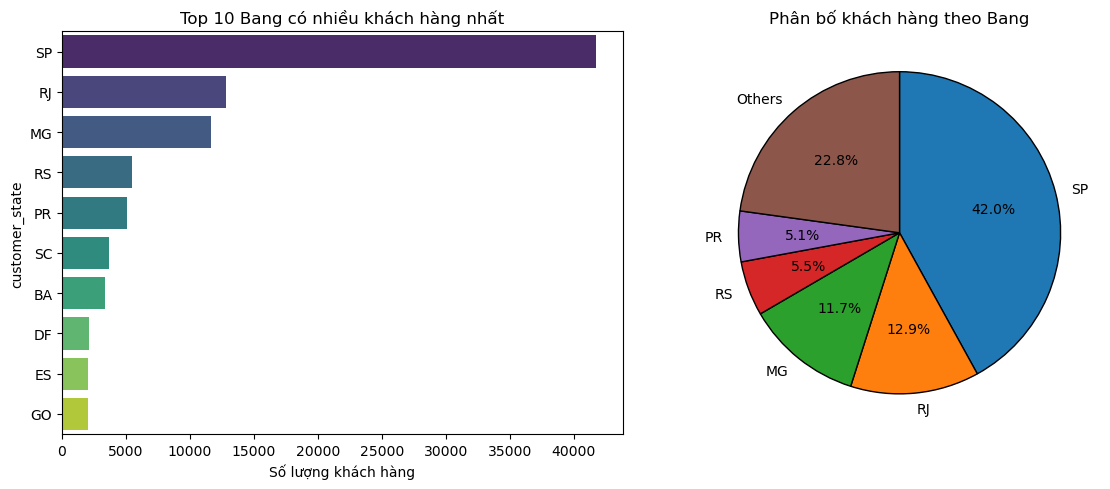


Top 10 Bang:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


In [6]:
# 3. Phân tích theo Bang (State)

state_counts = customers_data['customer_state'].value_counts()
top10_states = state_counts.head(10)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(x=top10_states.values, y=top10_states.index, palette='viridis')
plt.title('Top 10 Bang có nhiều khách hàng nhất')
plt.xlabel('Số lượng khách hàng')

# Sắp xếp giảm dần
state_counts = state_counts.sort_values(ascending=False)


top5 = state_counts.head(5)

# Gộp phần còn lại
others = state_counts.iloc[5:].sum()

# Tạo data mới
labels = list(top5.index) + ['Others']
values = list(top5.values) + [others]

# Vẽ pie chart
plt.subplot(1,2,2)
plt.pie(values, labels=labels,
        autopct='%1.1f%%',
        startangle=90,          
        counterclock=False,     
        wedgeprops={'edgecolor':'black'})

plt.title('Phân bố khách hàng theo Bang')
plt.tight_layout()
plt.show()

print("\nTop 10 Bang:")
print(top10_states)

C:\Users\huyho\AppData\Local\Temp\ipykernel_15596\3108662309.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15_cities.values, y=top15_cities.index, palette='rocket')


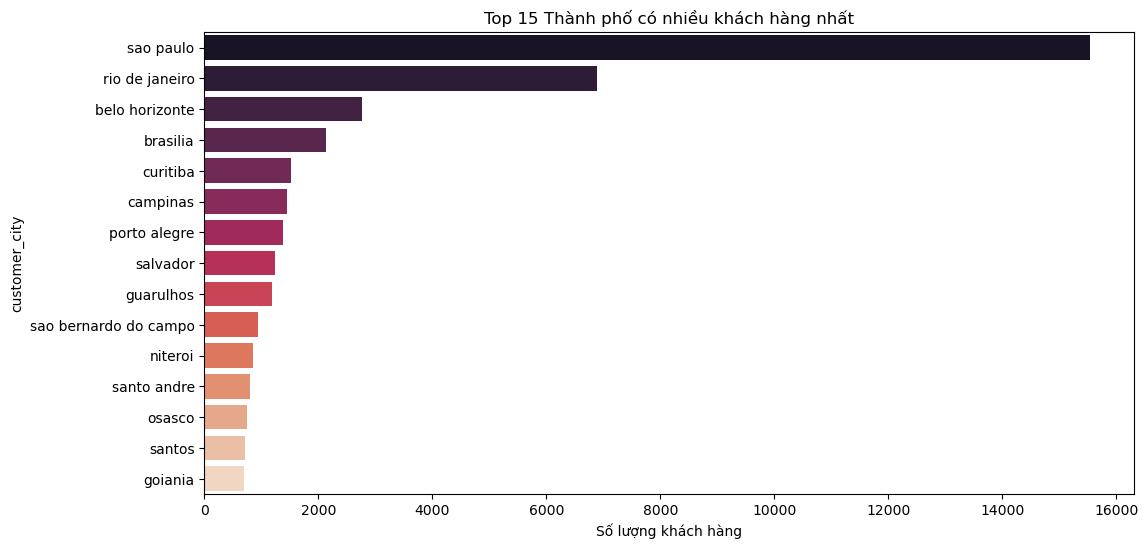


Top 15 thành phố:
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
niteroi                    849
santo andre                797
osasco                     746
santos                     713
goiania                    692
Name: count, dtype: int64


In [7]:
# 4. Phân tích theo Thành phố

city_counts = customers_data['customer_city'].value_counts()
top15_cities = city_counts.head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top15_cities.values, y=top15_cities.index, palette='rocket')
plt.title('Top 15 Thành phố có nhiều khách hàng nhất')
plt.xlabel('Số lượng khách hàng')
plt.show()

print("\nTop 15 thành phố:")
print(top15_cities)

Text(0.5, 0, 'Zip Code Prefix')

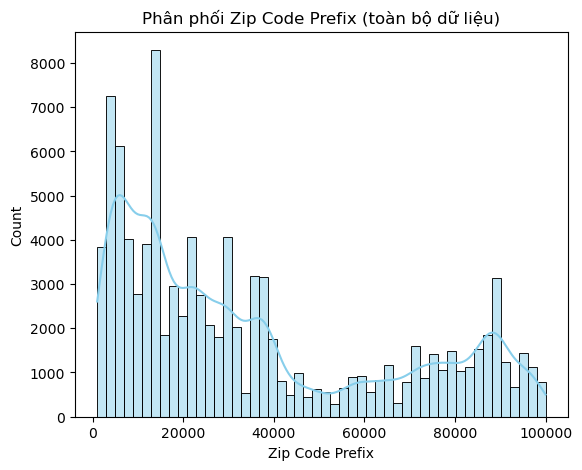

In [8]:
# 5. Phân phối ZIP Code
# Cột customer_zip_code_prefix là số nguyên (3-5 chữ số)
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(customers_data['customer_zip_code_prefix'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối Zip Code Prefix (toàn bộ dữ liệu)')
plt.xlabel('Zip Code Prefix')

C:\Users\huyho\AppData\Local\Temp\ipykernel_15596\3065254107.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_states, x='customer_state', y='customer_zip_code_prefix', palette='Set2')


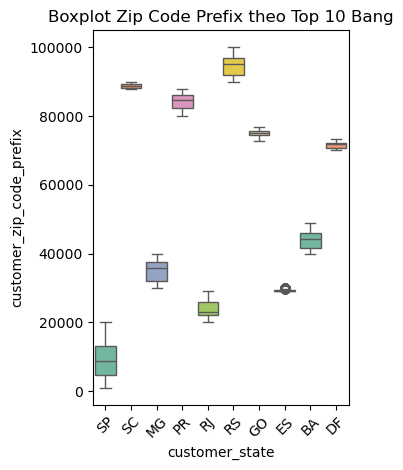

In [13]:
# Boxplot theo từng bang (chỉ lấy 10 bang có nhiều KH nhất để dễ nhìn)
top_states_for_box = state_counts.head(10).index
df_top_states = customers_data[customers_data['customer_state'].isin(top_states_for_box)]

plt.subplot(1,2,2)
sns.boxplot(data=df_top_states, x='customer_state', y='customer_zip_code_prefix', palette='Set2')
plt.title('Boxplot Zip Code Prefix theo Top 10 Bang')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Tổng số khách hàng duy nhất: 96096
Khách hàng chỉ mua 1 lần (one-time): 93099 (96.88%)
Khách hàng mua từ 2 lần trở lên (returning): 2997 (3.12%)


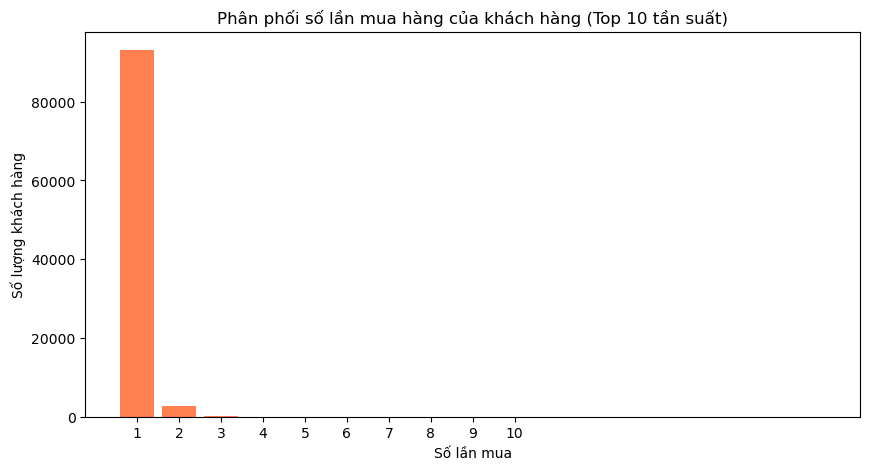

In [12]:
# 6. Khách hàng quay lại (Returning Customers)
# ============================================
# Mỗi khách hàng được định danh bởi customer_unique_id
# Đếm số lần xuất hiện của mỗi unique_id (mỗi lần là một đơn hàng)
customer_freq = customers_data['customer_unique_id'].value_counts()

one_time = (customer_freq == 1).sum()
returning = (customer_freq > 1).sum()

print(f"\nTổng số khách hàng duy nhất: {len(customer_freq)}")
print(f"Khách hàng chỉ mua 1 lần (one-time): {one_time} ({one_time/len(customer_freq)*100:.2f}%)")
print(f"Khách hàng mua từ 2 lần trở lên (returning): {returning} ({returning/len(customer_freq)*100:.2f}%)")

# Phân phối tần suất mua hàng
freq_dist = customer_freq.value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(freq_dist.index[:10], freq_dist.values[:10], color='coral')
plt.title('Phân phối số lần mua hàng của khách hàng (Top 10 tần suất)')
plt.xlabel('Số lần mua')
plt.ylabel('Số lượng khách hàng')
plt.xticks(range(1,11))
plt.show()


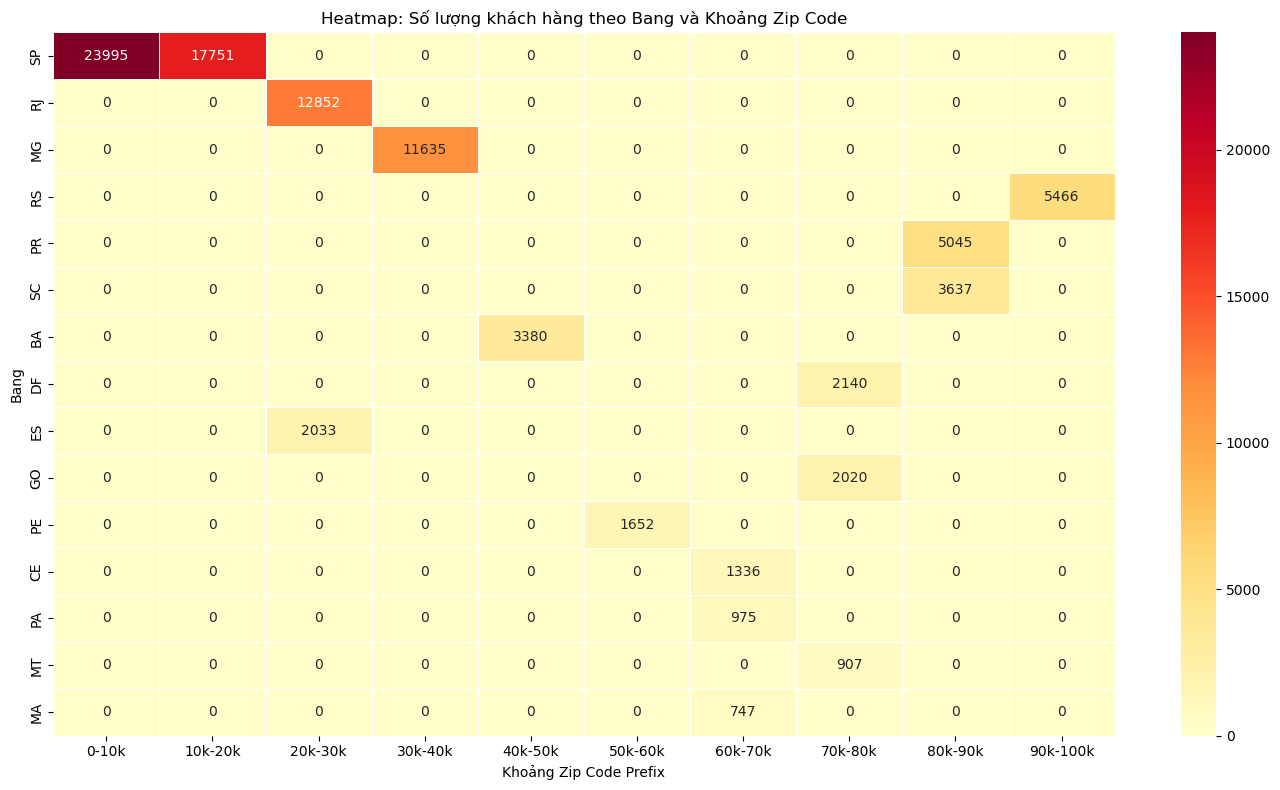

In [14]:
# 7. Heatmap Bang × ZIP Range
# ============================================
# Chia zip code prefix thành các khoảng (range)
bins = [0, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000]
labels = ['0-10k', '10k-20k', '20k-30k', '30k-40k', '40k-50k',
          '50k-60k', '60k-70k', '70k-80k', '80k-90k', '90k-100k']
customers_data['zip_range'] = pd.cut(customers_data['customer_zip_code_prefix'], bins=bins, labels=labels, right=False)

# Tạo bảng chéo giữa state và zip_range
cross_tab = pd.crosstab(customers_data['customer_state'], customers_data['zip_range'])

# Vẽ heatmap (chỉ lấy 15 bang đầu để dễ nhìn)
top_states_heat = state_counts.head(15).index
cross_tab_top = cross_tab.loc[top_states_heat]

plt.figure(figsize=(14,8))
sns.heatmap(cross_tab_top, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap: Số lượng khách hàng theo Bang và Khoảng Zip Code')
plt.xlabel('Khoảng Zip Code Prefix')
plt.ylabel('Bang')
plt.tight_layout()
plt.show()


In [16]:
# 8. Tóm tắt & Insights
# ============================================
print("\n" + "="*60)
print("TÓM TẮT & INSIGHTS CHÍNH")
print("="*60)

print(f"1. Tổng số khách hàng (số dòng): {customers_data.shape[0]}")
print(f"2. Số lượng khách hàng duy nhất: {customers_data['customer_unique_id'].nunique()}")
print(f"3. Số bang xuất hiện: {customers_data['customer_state'].nunique()}")
print(f"4. Số thành phố xuất hiện: {customers_data['customer_city'].nunique()}")

# Bang có nhiều khách nhất
top_state = state_counts.index[0]
print(f"5. Bang có nhiều khách hàng nhất: {top_state} với {state_counts.iloc[0]} khách ({state_counts.iloc[0]/customers_data.shape[0]*100:.1f}%)")

# Thành phố có nhiều khách nhất
top_city = city_counts.index[0]
print(f"6. Thành phố có nhiều khách hàng nhất: {top_city} với {city_counts.iloc[0]} khách")

# Về khách hàng quay lại
print(f"7. Tỉ lệ khách hàng quay lại (mua >=2 lần): {returning/len(customer_freq)*100:.2f}%")
print(f"8. Hầu hết khách hàng (>{one_time/len(customer_freq)*100:.1f}%) chỉ mua một lần, cho thấy hoạt động mua sắm chủ yếu là một lần.")

# Zip code phân bố rộng, tập trung nhiều ở các khu vực đô thị lớn (São Paulo, Rio, ...)
print("9. Zip code prefix phân bố không đều, tập trung nhiều ở các thành phố lớn (boxplot cho thấy sự chênh lệch giữa các bang).")
print("10. Heatmap cho thấy mối tương quan giữa bang và dải mã zip: các bang có mật độ cao thường nằm trong khoảng zip thấp (khu vực trung tâm).")


TÓM TẮT & INSIGHTS CHÍNH
1. Tổng số khách hàng (số dòng): 99441
2. Số lượng khách hàng duy nhất: 96096
3. Số bang xuất hiện: 27
4. Số thành phố xuất hiện: 4119
5. Bang có nhiều khách hàng nhất: SP với 41746 khách (42.0%)
6. Thành phố có nhiều khách hàng nhất: sao paulo với 15540 khách
7. Tỉ lệ khách hàng quay lại (mua >=2 lần): 3.12%
8. Hầu hết khách hàng (>96.9%) chỉ mua một lần, cho thấy hoạt động mua sắm chủ yếu là một lần.
9. Zip code prefix phân bố không đều, tập trung nhiều ở các thành phố lớn (boxplot cho thấy sự chênh lệch giữa các bang).
10. Heatmap cho thấy mối tương quan giữa bang và dải mã zip: các bang có mật độ cao thường nằm trong khoảng zip thấp (khu vực trung tâm).
